In [ ]:
import numpy as np
import pandas as pd

In [ ]:
def train(X, labels):
  weights = 1.5 * np.random.rand(len(X.columns) + 1)
  X["bias"] = np.ones(X.shape[0])
  X = X.astype(np.float64)
  weights = weights.astype(np.float64)
  labels = labels.astype(np.float64)
  flag = 1

  while True:
      for index, row in X.iterrows():
          xi = np.array(row)
          yi = labels.loc[index]

          if np.dot(xi, weights) * yi <= 0:
              if np.dot(xi, weights) < 0:
                  weights = weights + xi
              else:
                  weights = weights - xi
              flag = 0

      if flag == 0:
          flag = 1
      else:
          break

  return weights

In [ ]:
import random

In [ ]:
from sklearn.datasets import make_blobs, make_classification, make_gaussian_quantiles

X, Y = make_blobs(n_samples=10000, n_features=2, centers=2, random_state=42, cluster_std=1.0)
Y[Y == 0] = -1

df = pd.DataFrame({'x1': X[:, 0], 'x2': X[:, 1], 'y': Y})

In [ ]:
# x1 = 3 * np.random.randn(500)
# x2 = 5 * np.random.randn(500)
# y = np.zeros(500)
# y[x1 + x2 >= 0] = 1
# y[x1 + x2 < 0] = -1
# data = np.array([x1, x2, y]).T

In [ ]:
X = df.drop("y", axis=1)
Y = df["y"]
x1 = df["x1"]
x2 = df["x2"]

In [ ]:
weights = train(X, Y)
weights

array([ 9.86981909, -2.04971633,  1.38468765])

In [ ]:
l = []
# for index, rows in df.iterrows():
#   ans = 0
#   ans += rows["x1"]*weights[0] + rows["x2"]*weights[1] + weights[2]
#   l.append(ans)
for index, rows in df.iterrows():
  x3 = rows["x1"]
  x4 = -1 * (weights[2] + weights[0]*x3)
  x4 /= weights[1]
  l.append(x4)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
colors = np.where(Y == 1, 'red', 'blue')

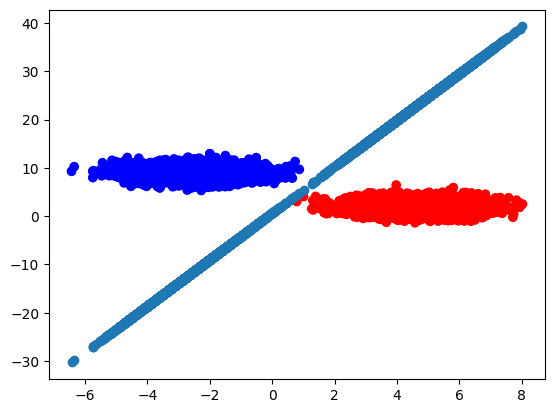

In [ ]:
plt.scatter(x1, x2, c=colors, label='First Set')
plt.scatter(list(df["x1"]), l, label='Second Set')